# EDA - Dataset REHAB (Rehab_exercise)

Analisis exploratorio de las 16 clases de movimiento, usando los 12 canales de
sensor (dos IMU + guante).

In [1]:
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

import sys
sys.path.append("../src")
from data_loader import build_dataset, MOVEMENT_NAMES
from features import extraer_features_por_muestra, nombres_columnas

DATA_DIR = "../data/raw"

sns.set_theme(style="whitegrid")

## 1. Balance de clases

In [2]:
X, y, meta = build_dataset(DATA_DIR, verbose=False)
print(f"X: {X.shape}   y: {y.shape}")
print(f"clases presentes: {len(np.unique(y))} de 16")

clases, conteos = np.unique(y, return_counts=True)
tabla_balance = pd.DataFrame({
    "clase": clases,
    "movimiento": [MOVEMENT_NAMES[c] for c in clases],
    "muestras": conteos,
    "porcentaje": (conteos / len(y) * 100).round(1),
})
tabla_balance.sort_values("muestras", ascending=False)

X: (4257, 880, 12)   y: (4257,)
clases presentes: 15 de 16


,clase,movimiento,muestras,porcentaje
7,7,ball gripping,385,9.0
13,13,ankle extension & knee internal/external rotation,313,7.4
14,15,hip flexion and extension,313,7.4
10,10,flexion-pressure rotation forward and backward,311,7.3
9,9,breast expansion,307,7.2
8,8,shoulder joint internal and external rotation,299,7.0
5,5,wrist flexion and extension,293,6.9
12,12,shoulder touch training,293,6.9
4,4,elbow flexion and wrist compression,287,6.7
2,2,bobath forward flexion/extension,267,6.3


entropia de Shannon: 3.892 bits (maxima posible: 3.907)
razon clase mayoritaria/minoritaria: 1.82:1


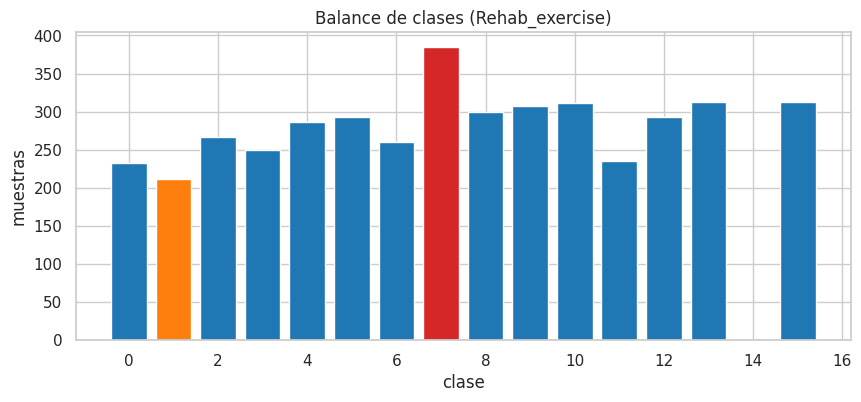

In [3]:
probs = conteos / conteos.sum()
entropia = -(probs * np.log2(probs)).sum()
print(f"entropia de Shannon: {entropia:.3f} bits (maxima posible: {np.log2(len(clases)):.3f})")
print(f"razon clase mayoritaria/minoritaria: {conteos.max()/conteos.min():.2f}:1")

fig, ax = plt.subplots(figsize=(10, 4))
colores = ["#d62728" if c == conteos.max() else "#1f77b4" if c != conteos.min() else "#ff7f0e" for c in conteos]
ax.bar(clases, conteos, color=colores)
ax.set_xlabel("clase")
ax.set_ylabel("muestras")
ax.set_title("Balance de clases (Rehab_exercise)")
plt.show()

El movimiento 14 no aparece porque su archivo de sensor IMU esta corrupto en la
fuente y se excluye en `data_loader.py`. El resto de las clases tienen entre 212 y
385 muestras, una razon de ~1.8:1 entre la mas grande y la mas chica.

## 2. Duplicados exactos

In [4]:
def tasa_duplicados_por_clase(X, y):
    filas = []
    for clase in np.unique(y):
        idx = np.where(y == clase)[0]
        hashes = [hashlib.md5(X[i].tobytes()).hexdigest() for i in idx]
        n_unicos = len(set(hashes))
        n_total = len(hashes)
        filas.append({
            "clase": clase,
            "movimiento": MOVEMENT_NAMES[clase],
            "muestras": n_total,
            "unicas": n_unicos,
            "duplicadas_%": round(100 * (1 - n_unicos / n_total), 1),
        })
    return pd.DataFrame(filas)

tabla_dup = tasa_duplicados_por_clase(X, y)
tabla_dup.sort_values("duplicadas_%", ascending=False)

,clase,movimiento,muestras,unicas,duplicadas_%
2,2,bobath forward flexion/extension,267,171,36.0
14,15,hip flexion and extension,313,212,32.3
12,12,shoulder touch training,293,202,31.1
0,0,bobath handshake,232,178,23.3
3,3,bobath anterior/posterior rotation,250,200,20.0
10,10,flexion-pressure rotation forward and backward,311,249,19.9
11,11,elbow joint flexion and touch,235,190,19.1
6,6,finger-to-finger training,260,212,18.5
13,13,ankle extension & knee internal/external rotation,313,275,12.1
1,1,bobath flexion/extension,212,193,9.0


Varias clases tienen un porcentaje alto de muestras que son copias exactas byte a
byte entre si (hasta ~64% en algunos movimientos). Hay que tenerlo en cuenta al
hacer el split train/test para no dejar la misma muestra en ambos conjuntos.

## 3. Correlacion entre canales

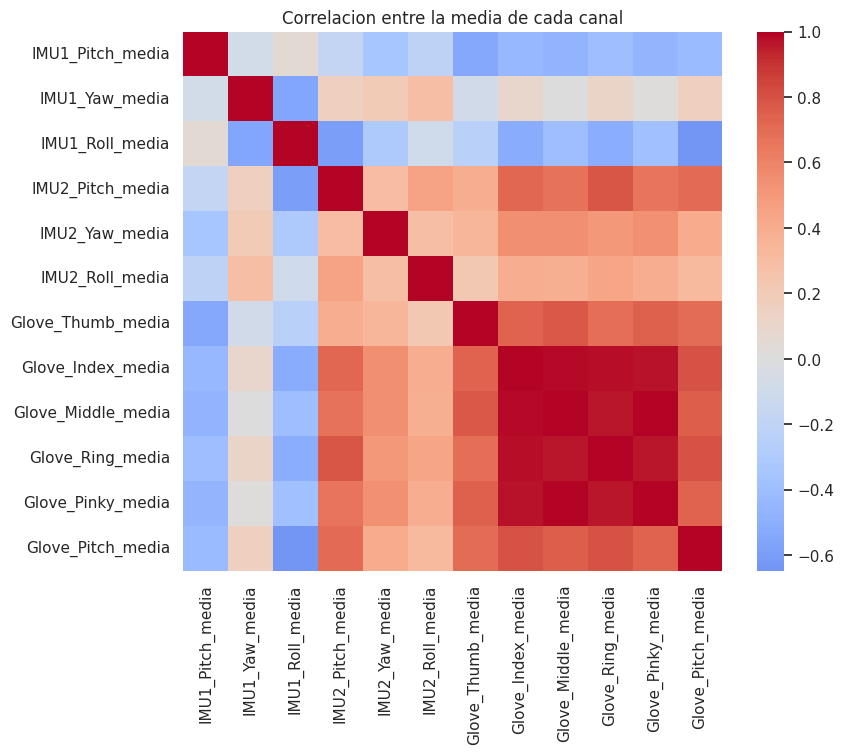

In [5]:
features = extraer_features_por_muestra(X)
df_features = pd.DataFrame(features, columns=nombres_columnas())
df_features["movimiento_id"] = y

medias = [c for c in df_features.columns if c.endswith("_media")]
corr = df_features[medias].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlacion entre la media de cada canal")
plt.show()

Los canales del mismo sensor IMU (pitch/yaw/roll) estan mas correlacionados entre
si que con los del guante, y algunos dedos del guante tambien se mueven juntos en
varios movimientos.

## 4. Separabilidad de clases (PCA)

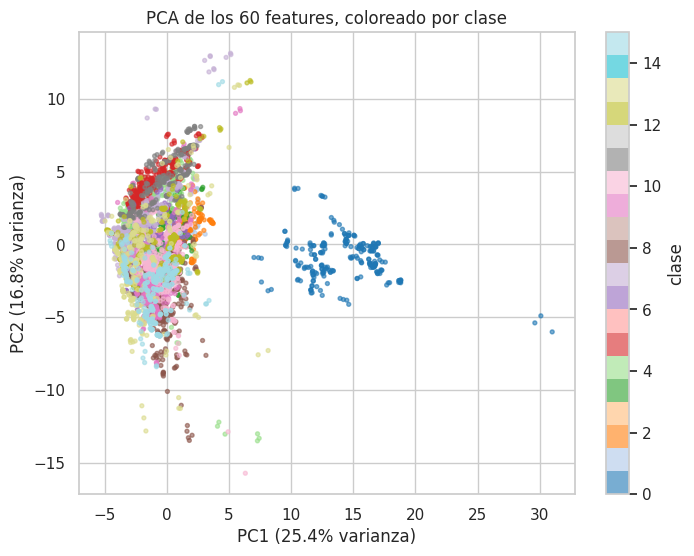

In [6]:
X_pca_input = (features - features.mean(axis=0)) / features.std(axis=0)
pca = PCA(n_components=2, random_state=42)
proyeccion = pca.fit_transform(X_pca_input)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(proyeccion[:, 0], proyeccion[:, 1], c=y, cmap="tab20", s=8, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA de los 60 features, coloreado por clase")
plt.colorbar(scatter, label="clase")
plt.show()

Se ven agrupamientos parciales por clase, con traslape entre movimientos
parecidos (las variantes de "bobath", por ejemplo). Las clases no son perfectamente
separables en 2D, lo que sugiere que un modelo no lineal deberia funcionar mejor
que uno lineal sobre este conjunto de features.

## 5. Resumen

- 15 de 16 clases disponibles, desbalance moderado (~1.8:1).
- Hay duplicados exactos dentro de varias clases, relevante para el split.
- Los canales del mismo sensor estan correlacionados entre si.
- Las clases muestran estructura en PCA pero con traslape entre movimientos
  similares.